In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [9]:
df=pd.read_csv("blinkit_orders.csv")

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   object 
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.8+ KB


In [11]:
df.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741


In [15]:
required_columns = ['order_date', 'store_id','order_total', 'order_id']
df_filtered = df[required_columns].copy()


In [16]:
df_filtered['order_date']=pd.to_datetime(df_filtered['order_date'])

In [19]:
df_filtered['date_only'] =df_filtered['order_date'].dt.date

In [20]:
df_filtered['hour'] = df_filtered['order_date'].dt.hour
df_filtered['day_of_week'] = df_filtered['order_date'].dt.day_name()

In [21]:
df_filtered.head()

,order_date,store_id,order_total,order_id,date_only,hour,day_of_week
0,2024-07-17 08:34:01,4771,3197.07,1961864118,2024-07-17,8,Wednesday
1,2024-05-28 13:14:29,7534,976.55,1549769649,2024-05-28,13,Tuesday
2,2024-09-23 13:07:12,9886,839.05,9185164487,2024-09-23,13,Monday
3,2023-11-24 16:16:56,7917,440.23,9644738826,2023-11-24,16,Friday
4,2023-11-20 05:00:39,2741,2526.68,5427684290,2023-11-20,5,Monday


In [22]:
ts_data = df_filtered.groupby(['date_only', 'store_id']).agg({
    'order_total': 'sum',    # Revenue
    'order_id': 'count'      # Number of orders (Demand Volume)
}).reset_index()

# Rename columns for clarity
ts_data.columns = ['date', 'store_id', 'total_revenue', 'demand_volume']

# Ensure the 'date' is back to datetime format for rolling calculations
ts_data['date'] = pd.to_datetime(ts_data['date'])
ts_data = ts_data.sort_values(by=['store_id', 'date'])

print("\nFinal Time Series Format (Daily Demand per Store):")
print(ts_data.head())


Final Time Series Format (Daily Demand per Store):
           date  store_id  total_revenue  demand_volume
3977 2024-07-02         1        1172.69              1
1491 2023-09-11         2          22.14              1
1748 2023-10-11         9        1599.11              1
3125 2024-03-21        12        1639.04              1
3697 2024-05-29        14         704.19              1


In [23]:
ts_data.head()

,date,store_id,total_revenue,demand_volume
3977,2024-07-02,1,1172.69,1
1491,2023-09-11,2,22.14,1
1748,2023-10-11,9,1599.11,1
3125,2024-03-21,12,1639.04,1
3697,2024-05-29,14,704.19,1


In [26]:
import holidays
from datetime import datetime

def get_india_features(start_date, end_date):
   
    dates = pd.date_range(start=start_date, end=end_date)
    df_features = pd.DataFrame({'date': dates})
    
    
    in_holidays = holidays.India()
    df_features['is_holiday'] = df_features['date'].apply(lambda x: 1 if x in in_holidays else 0)
    df_features['holiday_name'] = df_features['date'].apply(lambda x: in_holidays.get(x))
    
    # 3. Add Payday Flags (1st to 5th of every month)
    df_features['is_payday'] = df_features['date'].apply(lambda x: 1 if x.day <= 5 else 0)
    
    return df_features

# usage
df_hyperlocal = get_india_features('2023-01-01', '2025-12-31')

In [42]:
df_hyperlocal.head(27)

,date,is_holiday,holiday_name,is_payday
0,2023-01-01,0,None,1
1,2023-01-02,0,None,1
2,2023-01-03,0,None,1
3,2023-01-04,0,None,1
4,2023-01-05,0,None,1
5,2023-01-06,0,None,0
6,2023-01-07,0,None,0
7,2023-01-08,0,None,0
8,2023-01-09,0,None,0
9,2023-01-10,0,None,0


In [36]:
import openmeteo_requests

import requests

def fetch_weather(start_date, end_date):
    # delhi Coordinates
    params = {
        "latitude": 28.6139,
        "longitude": 77.2090,
        "start_date": start_date,
        "end_date": end_date,
        "daily": ["temperature_2m_max", "precipitation_sum", "rain_sum"],
        "timezone": "Asia/Kolkata"
    }
    
    # Simple GET request (No key needed for Open-Meteo)
    url = "https://archive-api.open-meteo.com/v1/archive"
    response = requests.get(url, params=params).json()
    
    # Parse the daily data
    daily = response['daily']
    weather_df = pd.DataFrame({
        "date": pd.to_datetime(daily['time']),
        "max_temp": daily['temperature_2m_max'],
        "rain_sum": daily['rain_sum']
    })
    
    # Categorical Weather Feature
    weather_df['is_rainy'] = (weather_df['rain_sum'] > 0.5).astype(int)
    
    return weather_df

# Fetching weather for Bhopal
df_weather = fetch_weather("2023-01-01", "2025-12-31")

In [43]:
df_weather.head()

,date,max_temp,rain_sum,is_rainy
0,2023-01-01,18.3,0.0,0
1,2023-01-02,18.1,0.0,0
2,2023-01-03,16.5,0.0,0
3,2023-01-04,16.5,0.0,0
4,2023-01-05,15.4,0.0,0


In [37]:
# 1. Ensure all date columns are in the same format (Datetime)
ts_data['date'] = pd.to_datetime(ts_data['date'])
df_hyperlocal['date'] = pd.to_datetime(df_hyperlocal['date'])
df_weather['date'] = pd.to_datetime(df_weather['date'])

# 2. Merge Time-Series with Holidays/Events first
# Use 'left' join to keep all sales data even if there's no holiday
df_final = pd.merge(ts_data, df_hyperlocal, on='date', how='left')

# 3. Merge with Weather data
df_final = pd.merge(df_final, df_weather, on='date', how='left')

# 4. Data Cleaning after Merge
# Holidays that aren't in the library will be NaN; fill them with 'None' or 0
df_final['is_holiday'] = df_final['is_holiday'].fillna(0)
df_final['holiday_name'] = df_final['holiday_name'].fillna('Regular Day')
df_final['is_payday'] = df_final['is_payday'].fillna(0)

# If weather data is missing for some days, use forward fill (assume today is like yesterday)
df_final[['max_temp', 'is_rainy']] = df_final[['max_temp', 'is_rainy']].ffill()

print("Master Dataset Integrated successfully!")
print(df_final.columns)

Master Dataset Integrated successfully!
Index(['date', 'store_id', 'total_revenue', 'demand_volume', 'is_holiday',
       'holiday_name', 'is_payday', 'max_temp', 'rain_sum', 'is_rainy'],
      dtype='object')


In [38]:
df_final.head()

,date,store_id,total_revenue,demand_volume,is_holiday,holiday_name,is_payday,max_temp,rain_sum,is_rainy
0,2024-07-02,1,1172.69,1,0,Regular Day,1,33.6,14.1,1
1,2023-09-11,2,22.14,1,0,Regular Day,0,32.1,1.0,1
2,2023-10-11,9,1599.11,1,0,Regular Day,0,33.7,0.0,0
3,2024-03-21,12,1639.04,1,0,Regular Day,0,29.1,0.0,0
4,2024-05-29,14,704.19,1,0,Regular Day,0,45.7,0.0,0


In [39]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           5000 non-null   datetime64[ns]
 1   store_id       5000 non-null   int64         
 2   total_revenue  5000 non-null   float64       
 3   demand_volume  5000 non-null   int64         
 4   is_holiday     5000 non-null   int64         
 5   holiday_name   5000 non-null   object        
 6   is_payday      5000 non-null   int64         
 7   max_temp       5000 non-null   float64       
 8   rain_sum       5000 non-null   float64       
 9   is_rainy       5000 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(5), object(1)
memory usage: 390.8+ KB


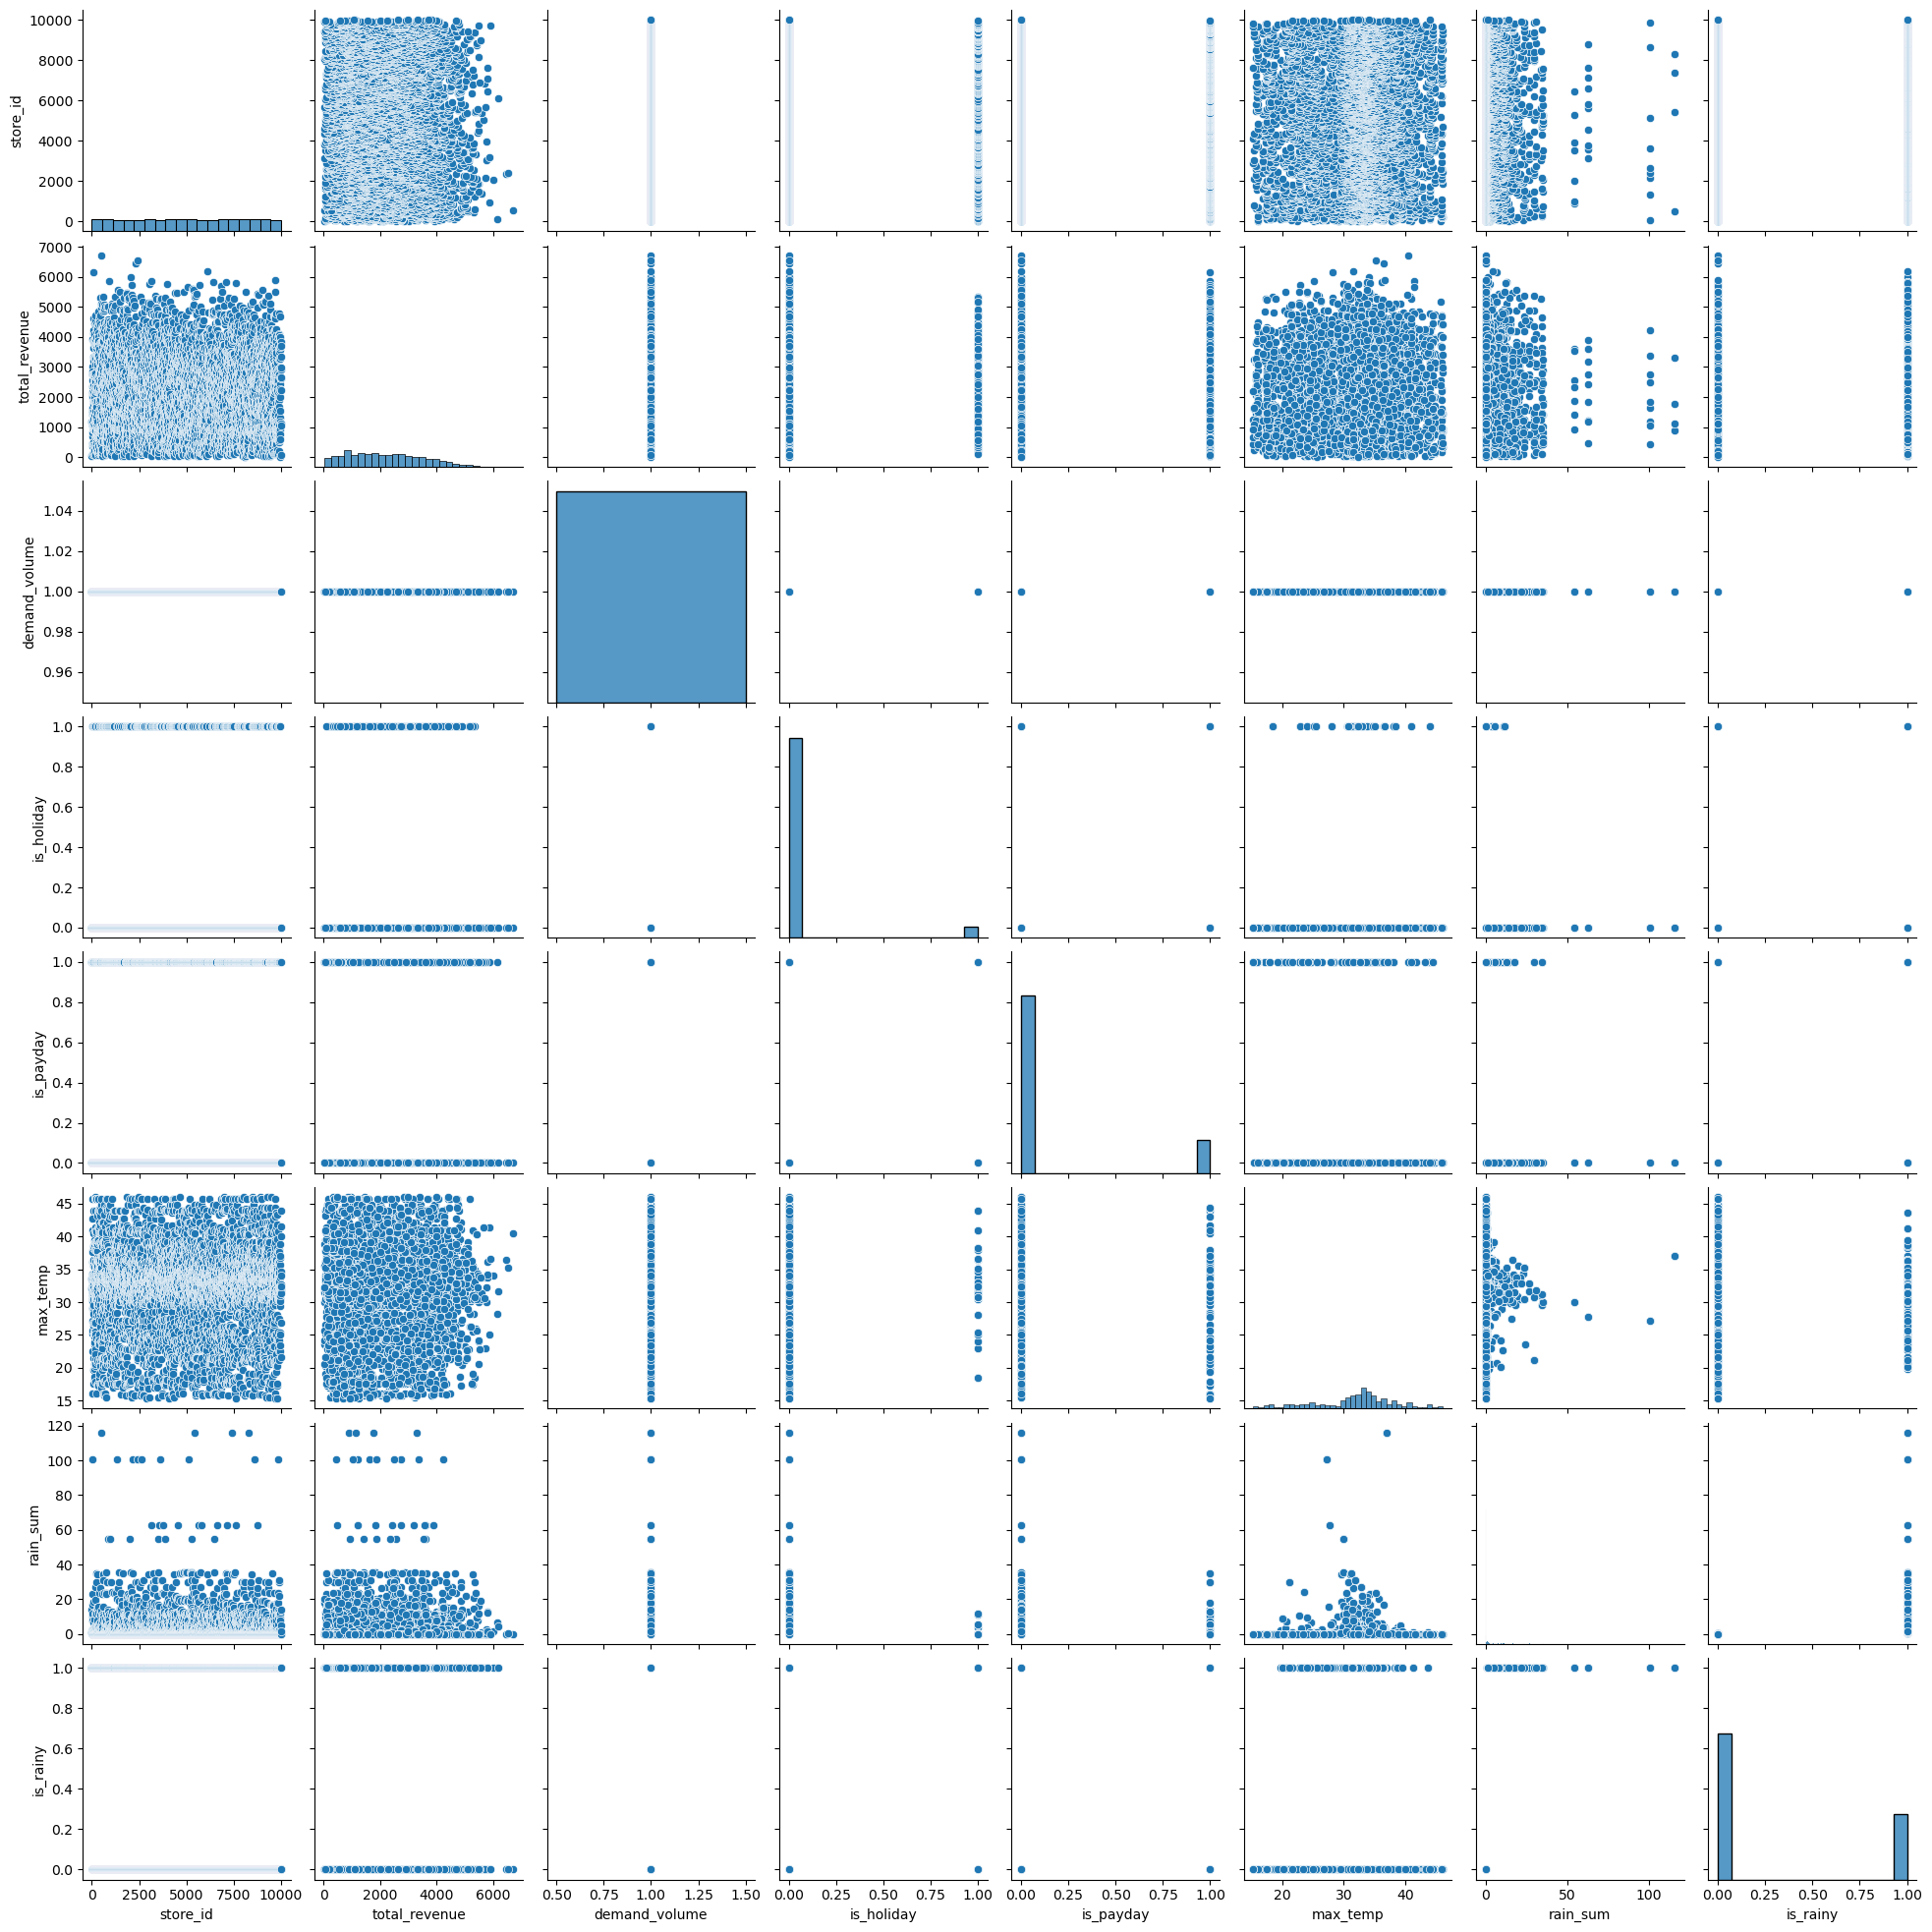

In [40]:
sns.pairplot(df_final)